# Кейс 5: метрические методы классификации

## Постановка задачи
Цель работы — реализовать и сравнить метрические методы классификации. В исследовании проверяется, как на качество влияют расстояние между объектами, число соседей, ширина окна Парзена, тип ядра и масштабирование признаков.

## Основные задачи
1. Реализовать 1NN, kNN, weighted-kNN и окна Парзена.
2. Реализовать взвешенную метрику Минковского.
3. Подобрать параметры методом LOO.
4. Проверить влияние масштабирования.
5. Построить границы классификации на make_moons.
6. Сравнить kNN и weighted-kNN при разном уровне шума.
7. Построить профиль компактности и сравнить его с ошибкой 1NN.
8. Проверить жадный отбор эталонов для ускорения 1NN.


В работе дана обучающая выборка объектов с известными классами. Используются метрические методы, потому что они напрямую связывают качество классификации с расстояниями между объектами.

**Обоснование использования методов:**
- 1NN показывает базовый вариант классификации по ближайшему объекту.
- kNN сглаживает решение, потому что учитывает несколько ближайших соседей.
- weighted-kNN проверяет идею, что близкие соседи должны влиять сильнее дальних.
- Окно Парзена показывает влияние радиуса окрестности и типа ядра.
- Профиль компактности помогает проверить, насколько близко расположены объекты одного класса.
- Жадный отбор эталонов нужен, чтобы ускорить 1NN и уменьшить число используемых объектов.


## Импорт библиотек


In [1]:

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import time
import warnings

from sklearn.datasets import load_iris, load_wine, load_breast_cancer, make_moons
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='FigureCanvasAgg is non-interactive*')
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

np.random.seed(42)
EPS = 1e-12


## Вспомогательные функции: масштабирование, метрика Минковского и метрики качества


In [2]:

def standardize_fit(X):
    """Вычисляет среднее и стандартное отклонение для стандартизации."""
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    std[std == 0] = 1.0
    return mean, std


def standardize_transform(X, mean, std):
    return (X - mean) / std


def standardize_all(X):
    """Стандартизация всей матрицы признаков. Используется для train/test-проверок и визуализации."""
    mean, std = standardize_fit(X)
    return standardize_transform(X, mean, std)


def minkowski_distances(X_query, X_train, p=2, feature_weights=None):
    """
    Матрица расстояний между объектами X_query и X_train.
    Возвращает массив размера len(X_query) x len(X_train).
    """
    X_query = np.asarray(X_query, dtype=float)
    X_train = np.asarray(X_train, dtype=float)

    if feature_weights is None:
        feature_weights = np.ones(X_train.shape[1])
    feature_weights = np.asarray(feature_weights, dtype=float)

    diff = np.abs(X_query[:, None, :] - X_train[None, :, :])
    weighted_power = feature_weights[None, None, :] * (diff ** p)
    return np.sum(weighted_power, axis=2) ** (1 / p)


def accuracy(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(y_true == y_pred)


def f1_macro(y_true, y_pred):
    """F1-macro без sklearn: считаем F1 отдельно по каждому классу и усредняем."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    classes = np.unique(np.concatenate([y_true, y_pred]))
    f1_values = []

    for cls in classes:
        tp = np.sum((y_true == cls) & (y_pred == cls))
        fp = np.sum((y_true != cls) & (y_pred == cls))
        fn = np.sum((y_true == cls) & (y_pred != cls))

        precision = tp / (tp + fp + EPS)
        recall = tp / (tp + fn + EPS)
        f1 = 2 * precision * recall / (precision + recall + EPS)
        f1_values.append(f1)

    return float(np.mean(f1_values))


## Ядра для окна Парзена


In [3]:

def kernel_function(u, kernel='gaussian'):
    u = np.asarray(u, dtype=float)

    if kernel == 'uniform':
        return (np.abs(u) <= 1).astype(float)

    if kernel == 'triangular':
        return np.maximum(1 - np.abs(u), 0)

    if kernel == 'epanechnikov':
        return 0.75 * np.maximum(1 - u ** 2, 0)

    if kernel == 'gaussian':
        return np.exp(-0.5 * u ** 2) / np.sqrt(2 * np.pi)

    raise ValueError(f'Неизвестное ядро: {kernel}')


KERNELS = ['uniform', 'triangular', 'epanechnikov', 'gaussian']


## Реализация классификаторов


In [4]:

def choose_class_by_scores(scores, classes, row_distances, y_train):
    """
    Выбирает класс с максимальной суммой голосов.
    При ничьей берётся класс ближайшего объекта среди классов-победителей.
    """
    if np.max(scores) <= 0:
        return y_train[np.argmin(row_distances)]

    best_positions = np.flatnonzero(scores == np.max(scores))
    if len(best_positions) == 1:
        return classes[best_positions[0]]

    best_classes = set(classes[best_positions])
    for idx in np.argsort(row_distances):
        if y_train[idx] in best_classes:
            return y_train[idx]

    return classes[best_positions[0]]


def predict_from_distances(D, y_train, method='knn', k=5, h=1.0, kernel='gaussian', weighted_scheme='inverse_rank'):
    """
    функция предсказания по уже посчитанной матрице расстояний
    D: матрица расстояний len(X_query) x len(X_train)
    """
    y_train = np.asarray(y_train)
    classes = np.unique(y_train)
    predictions = []

    for row in D:
        scores = np.zeros(len(classes), dtype=float)
        order = np.argsort(row)

        if method == '1nn':
            neighbor = order[0]
            predictions.append(y_train[neighbor])
            continue

        if method in ['knn', 'weighted_knn']:
            kk = min(k, len(y_train))
            neighbors = order[:kk]

            if method == 'knn':
                weights = np.ones(kk)
            else:
                ranks = np.arange(1, kk + 1)
                if weighted_scheme == 'inverse_rank':
                    weights = 1 / ranks
                elif weighted_scheme == 'linear':
                    weights = kk - ranks + 1
                elif weighted_scheme == 'inverse_distance':
                    weights = 1 / (row[neighbors] + EPS)
                else:
                    raise ValueError('Неизвестная схема весов')

            for c_pos, cls in enumerate(classes):
                scores[c_pos] = weights[y_train[neighbors] == cls].sum()

            predictions.append(choose_class_by_scores(scores, classes, row, y_train))
            continue

        if method == 'parzen_fixed':
            u = row / max(h, EPS)
            weights = kernel_function(u, kernel=kernel)

            for c_pos, cls in enumerate(classes):
                scores[c_pos] = weights[y_train == cls].sum()

            predictions.append(choose_class_by_scores(scores, classes, row, y_train))
            continue

        if method == 'parzen_variable':
            # ширина окна равна расстоянию до (k + 1)-го соседа
            width_index = min(k, len(y_train) - 1)
            width = row[order[width_index]]
            if (not np.isfinite(width)) or width < EPS:
                width = EPS

            u = row / width
            weights = kernel_function(u, kernel=kernel)

            for c_pos, cls in enumerate(classes):
                scores[c_pos] = weights[y_train == cls].sum()

            predictions.append(choose_class_by_scores(scores, classes, row, y_train))
            continue

        raise ValueError(f'Неизвестный метод: {method}')

    return np.asarray(predictions)


def predict_metric_classifier(X_train, y_train, X_query, method='knn', p=2, k=5, h=1.0, kernel='gaussian', feature_weights=None):
    D = minkowski_distances(X_query, X_train, p=p, feature_weights=feature_weights)
    return predict_from_distances(D, y_train, method=method, k=k, h=h, kernel=kernel)


## LOO-контроль для оценки качества


In [5]:

def loo_distance_matrix(X, p=2, feature_weights=None, scale_inside=False):
    """
    Матрица расстояний для LOO.
    Если scale_inside=True, для каждой строки используется стандартизация по выборке без соответствующего объекта.
    Это эквивалентно делению координатных разностей на std, посчитанное без проверяемого объекта.
    """
    X = np.asarray(X, dtype=float)

    if not scale_inside:
        D = minkowski_distances(X, X, p=p, feature_weights=feature_weights)
        np.fill_diagonal(D, np.inf)
        return D

    n, d = X.shape
    if n <= 1:
        raise ValueError('Для LOO нужна выборка хотя бы из двух объектов')

    if feature_weights is None:
        feature_weights = np.ones(d)
    feature_weights = np.asarray(feature_weights, dtype=float)

    # std для обучающей части без i-го объекта, ddof=0 как в np.std(axis=0)
    sum_x = X.sum(axis=0)
    sum_x2 = (X ** 2).sum(axis=0)
    mean_leave = (sum_x[None, :] - X) / (n - 1)
    mean_x2_leave = (sum_x2[None, :] - X ** 2) / (n - 1)
    var_leave = np.maximum(mean_x2_leave - mean_leave ** 2, 0.0)
    std_leave = np.sqrt(var_leave)
    std_leave[std_leave == 0] = 1.0

    diff = np.abs(X[:, None, :] - X[None, :, :]) / std_leave[:, None, :]
    weighted_power = feature_weights[None, None, :] * (diff ** p)
    D = np.sum(weighted_power, axis=2) ** (1 / p)
    np.fill_diagonal(D, np.inf)
    return D


def loo_predictions(X, y, method='knn', p=2, k=5, h=1.0, kernel='gaussian', feature_weights=None, scale_inside=False):
    """
    Предсказания по leave-one-out.
    Если scale_inside=True, стандартизация выполняется без проверяемого объекта.
    """
    D = loo_distance_matrix(X, p=p, feature_weights=feature_weights, scale_inside=scale_inside)
    return predict_from_distances(D, y, method=method, k=k, h=h, kernel=kernel)


def loo_error(X, y, method='knn', p=2, k=5, h=1.0, kernel='gaussian', feature_weights=None, scale_inside=False):
    pred = loo_predictions(
        X, y, method=method, p=p, k=k, h=h, kernel=kernel,
        feature_weights=feature_weights, scale_inside=scale_inside
    )
    return 1 - accuracy(y, pred)


def get_h_values_for_p(h_values, p):
    """Передаём либо общий список h, либо словарь {p: список h}."""
    if isinstance(h_values, dict):
        return h_values[p]
    return h_values


def loo_score_table(X, y, method='knn', p_values=(1, 2, 3, 4), k_values=(1, 3, 5, 7, 9), h_values=None, kernels=KERNELS, scale_inside=False):
    rows = []

    if method == '1nn':
        for p in p_values:
            err = loo_error(X, y, method='1nn', p=p, k=1, scale_inside=scale_inside)
            rows.append({'method': method, 'p': p, 'k': 1, 'h': None, 'kernel': None, 'LOO_error': err})

    elif method in ['knn', 'weighted_knn']:
        for p in p_values:
            for k in k_values:
                err = loo_error(X, y, method=method, p=p, k=k, scale_inside=scale_inside)
                rows.append({'method': method, 'p': p, 'k': k, 'h': None, 'kernel': None, 'LOO_error': err})

    elif method == 'parzen_variable':
        for p in p_values:
            for kernel in kernels:
                for k in k_values:
                    err = loo_error(X, y, method='parzen_variable', p=p, k=k, kernel=kernel, scale_inside=scale_inside)
                    rows.append({'method': method, 'p': p, 'k': k, 'h': None, 'kernel': kernel, 'LOO_error': err})

    elif method == 'parzen_fixed':
        if h_values is None:
            raise ValueError('Для parzen_fixed нужно передать h_values')
        for p in p_values:
            for kernel in kernels:
                for h in get_h_values_for_p(h_values, p):
                    err = loo_error(X, y, method='parzen_fixed', p=p, h=h, kernel=kernel, scale_inside=scale_inside)
                    rows.append({'method': method, 'p': p, 'k': None, 'h': h, 'kernel': kernel, 'LOO_error': err})

    else:
        raise ValueError(f'Неизвестный метод: {method}')

    return pd.DataFrame(rows).sort_values('LOO_error').reset_index(drop=True)


## Загрузка датасетов


In [6]:

def load_real_datasets():
    datasets = {}

    iris = load_iris()
    datasets['Iris'] = (iris.data, iris.target)

    wine = load_wine()
    datasets['Wine'] = (wine.data, wine.target)

    cancer = load_breast_cancer()
    datasets['Breast Cancer'] = (cancer.data, cancer.target)

    return datasets


real_datasets = load_real_datasets()

for name, (X, y) in real_datasets.items():
    print(f'{name}: X = {X.shape}, classes = {np.unique(y)}')


Iris: X = (150, 4), classes = [0 1 2]
Wine: X = (178, 13), classes = [0 1 2]
Breast Cancer: X = (569, 30), classes = [0 1]


## Эксперимент: влияние масштабирования


In [7]:

def evaluate_scaling_effect(X, y, dataset_name, method='knn', k=5, p=2):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    rows = []

    for use_scaling in [False, True]:
        if use_scaling:
            mean, std = standardize_fit(X_train)
            X_train_used = standardize_transform(X_train, mean, std)
            X_test_used = standardize_transform(X_test, mean, std)
        else:
            X_train_used = X_train.copy()
            X_test_used = X_test.copy()

        y_pred = predict_metric_classifier(
            X_train_used, y_train, X_test_used,
            method=method, k=k, p=p
        )

        rows.append({
            'dataset': dataset_name,
            'scaling': use_scaling,
            'method': method,
            'k': k,
            'p': p,
            'accuracy': accuracy(y_test, y_pred),
            'F1_macro': f1_macro(y_test, y_pred)
        })

    return rows


scaling_rows = []
for name, (X, y) in real_datasets.items():
    scaling_rows.extend(evaluate_scaling_effect(X, y, name, method='knn', k=5, p=2))

scaling_table = pd.DataFrame(scaling_rows)
scaling_table


,dataset,scaling,method,k,p,accuracy,F1_macro
0,Iris,False,knn,5,2,0.977778,0.977753
1,Iris,True,knn,5,2,0.911111,0.909502
2,Wine,False,knn,5,2,0.666667,0.666739
3,Wine,True,knn,5,2,0.944444,0.944056
4,Breast Cancer,False,knn,5,2,0.923977,0.918586
5,Breast Cancer,True,knn,5,2,0.959064,0.955237


## Вывод по масштабированию
Масштабирование улучшило качество на Wine и Breast Cancer, так как признаки в этих датасетах имеют разные диапазоны значений. На Iris результат без масштабирования оказался выше на выбранном разбиении, поэтому по Iris нельзя делать общий вывод только по одному train/test-разделению.

## Подбор параметров через LOO


In [8]:

def make_k_grid(n_samples):
    candidates = [1, 3, 5, 7, 9, 15]
    # Для переменного окна нужна ширина по (k + 1)-му соседу, поэтому k должен быть меньше n - 1.
    return [k for k in candidates if k < n_samples - 1]


def make_h_grid(X, p=2):
    D = minkowski_distances(X, X, p=p)
    values = D[np.triu_indices_from(D, k=1)]
    values = values[values > EPS]
    quantiles = [0.05, 0.1, 0.2, 0.35]
    return np.unique(np.quantile(values, quantiles))


def search_best_params_for_dataset(X, y, dataset_name, use_scaling=True):
    # Для LOO при use_scaling=True стандартизация выполняется внутри каждого шага.
    # Для сетки h используем стандартизированную матрицу только как способ задать разумные кандидаты ширины окна.
    X_used = np.asarray(X, dtype=float)
    scale_inside = bool(use_scaling)
    X_for_h = standardize_all(X_used) if use_scaling else X_used.copy()

    p_values = [1, 2, 3]
    k_values = make_k_grid(len(X_used))
    h_values_by_p = {p: make_h_grid(X_for_h, p=p) for p in p_values}

    tables = []

    for method in ['1nn', 'knn', 'weighted_knn', 'parzen_variable']:
        table = loo_score_table(
            X_used, y,
            method=method,
            p_values=p_values,
            k_values=k_values,
            kernels=KERNELS,
            scale_inside=scale_inside
        )
        tables.append(table.head(5))

    parzen_fixed_table = loo_score_table(
        X_used, y,
        method='parzen_fixed',
        p_values=p_values,
        h_values=h_values_by_p,
        kernels=KERNELS,
        scale_inside=scale_inside
    )
    tables.append(parzen_fixed_table.head(5))

    result = pd.concat(tables, ignore_index=True)
    result.insert(0, 'dataset', dataset_name)
    result['LOO_quality'] = 1 - result['LOO_error']
    return result.sort_values(['LOO_error', 'method']).reset_index(drop=True)


all_best_rows = []
for name in ['Iris', 'Wine']:
    # Полный LOO-подбор делаем для Iris и Wine.
    # Breast Cancer больше по размеру, поэтому он используется в экспериментах с масштабированием и профилем компактности.
    X, y = real_datasets[name]
    print(f'Подбор параметров для {name}...')
    best_table = search_best_params_for_dataset(X, y, name, use_scaling=True)
    all_best_rows.append(best_table)

best_params_table = pd.concat(all_best_rows, ignore_index=True)
best_params_table


Подбор параметров для Iris...
Подбор параметров для Wine...


,dataset,method,p,k,h,kernel,LOO_error,LOO_quality
0,Iris,knn,2,15,NaN,None,0.033333,0.966667
1,Iris,knn,3,15,NaN,None,0.033333,0.966667
2,Iris,parzen_variable,2,15,NaN,uniform,0.033333,0.966667
3,Iris,parzen_variable,2,15,NaN,epanechnikov,0.033333,0.966667
4,Iris,parzen_variable,3,15,NaN,uniform,0.033333,0.966667
5,Iris,knn,2,7,NaN,None,0.040000,0.960000
6,Iris,knn,1,15,NaN,None,0.040000,0.960000
7,Iris,knn,3,9,NaN,None,0.040000,0.960000
8,Iris,parzen_fixed,2,None,0.585856,gaussian,0.040000,0.960000
9,Iris,parzen_variable,2,7,NaN,uniform,0.040000,0.960000


## Вывод по подбору параметров
Качество метрических методов зависит от выбора параметров: числа соседей k, параметра метрики p, ширины окна Парзена h и типа ядра. Поэтому параметры нужно подбирать экспериментально


## Графики зависимости LOO-ошибки от параметров


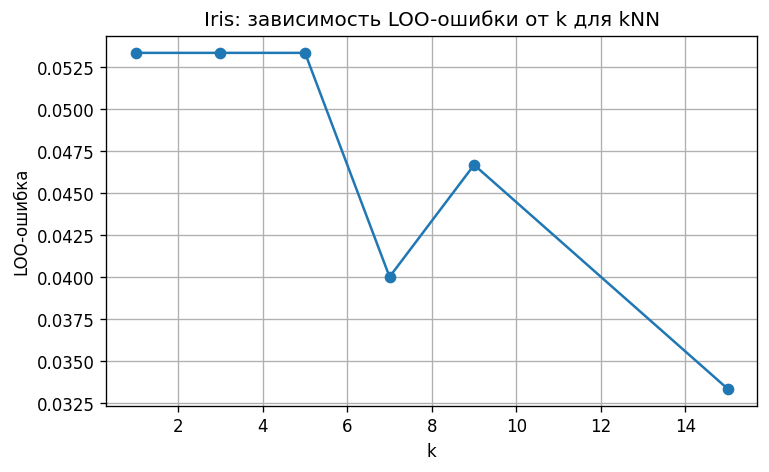

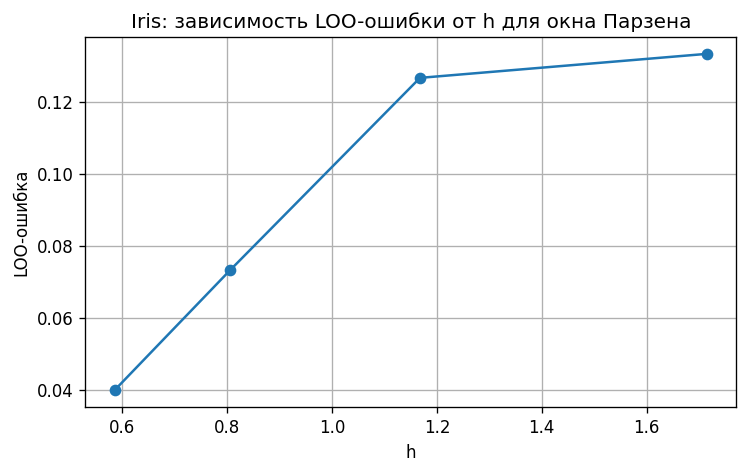

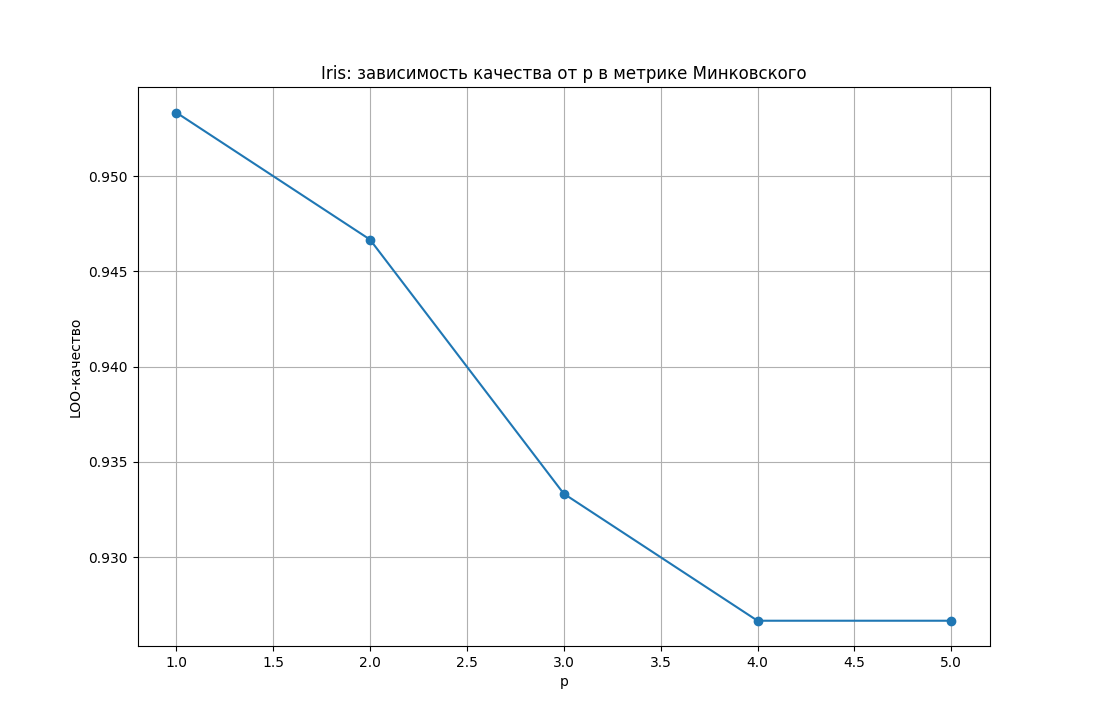

In [9]:

X_iris, y_iris = real_datasets['Iris']
X_iris_scaled_for_h = standardize_all(X_iris)

# 1) LOO-ошибка от k
k_values = make_k_grid(len(X_iris))
errors_k = [loo_error(X_iris, y_iris, method='knn', p=2, k=k, scale_inside=True) for k in k_values]

plt.figure(figsize=(7, 4))
plt.plot(k_values, errors_k, marker='o')
plt.xlabel('k')
plt.ylabel('LOO-ошибка')
plt.title('Iris: зависимость LOO-ошибки от k для kNN')
plt.grid(True)
plt.show()

# 2) LOO-ошибка от h
h_values = make_h_grid(X_iris_scaled_for_h, p=2)
errors_h = [loo_error(X_iris, y_iris, method='parzen_fixed', p=2, h=h, kernel='gaussian', scale_inside=True) for h in h_values]

plt.figure(figsize=(7, 4))
plt.plot(h_values, errors_h, marker='o')
plt.xlabel('h')
plt.ylabel('LOO-ошибка')
plt.title('Iris: зависимость LOO-ошибки от h для окна Парзена')
plt.grid(True)
plt.show()

# 3) Качество от p. Здесь качество = 1 - LOO-ошибка.
p_values = [1, 2, 3, 4, 5]
quality_p = [1 - loo_error(X_iris, y_iris, method='knn', p=p, k=5, scale_inside=True) for p in p_values]

plt.figure(figsize=(7, 4))
plt.plot(p_values, quality_p, marker='o')
plt.xlabel('p')
plt.ylabel('LOO-качество')
plt.title('Iris: зависимость качества от p в метрике Минковского')
plt.grid(True)
plt.show()


## Вывод по графикам
Для Iris лучше всего сработали умеренно большое число соседей, небольшая ширина окна Парзена и меньшее значение параметра p. На третьем графике показано LOO-качество, то есть величина 1 − LOO-ошибка.

## Карты классификации и границы решения на make_moons

На картах цветом показаны области классов, а линией дополнительно выделена граница решения.

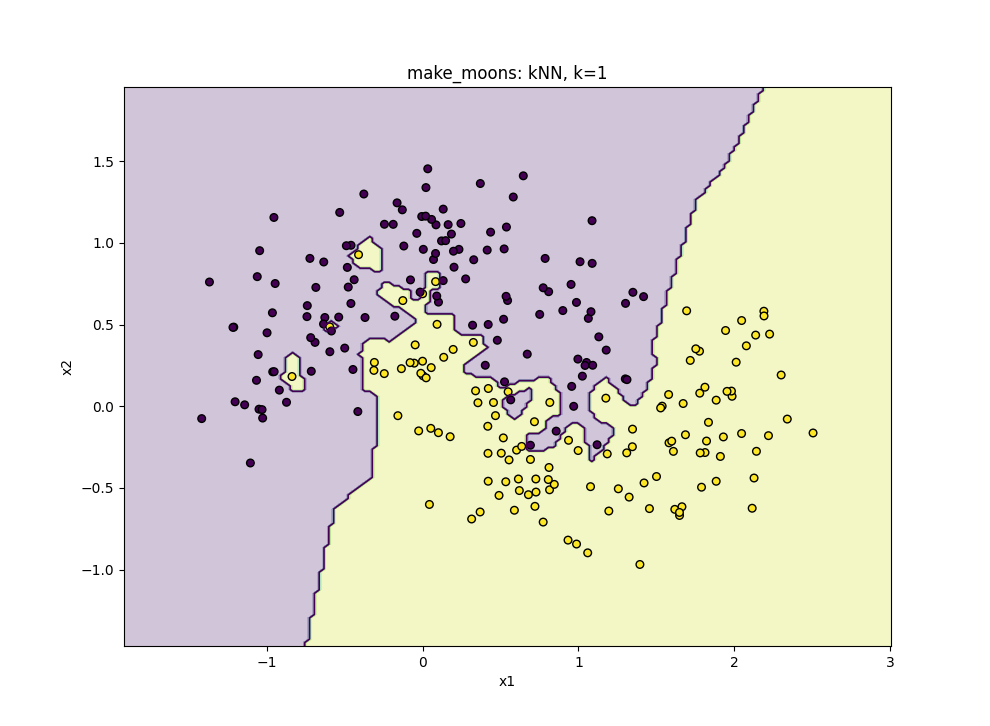

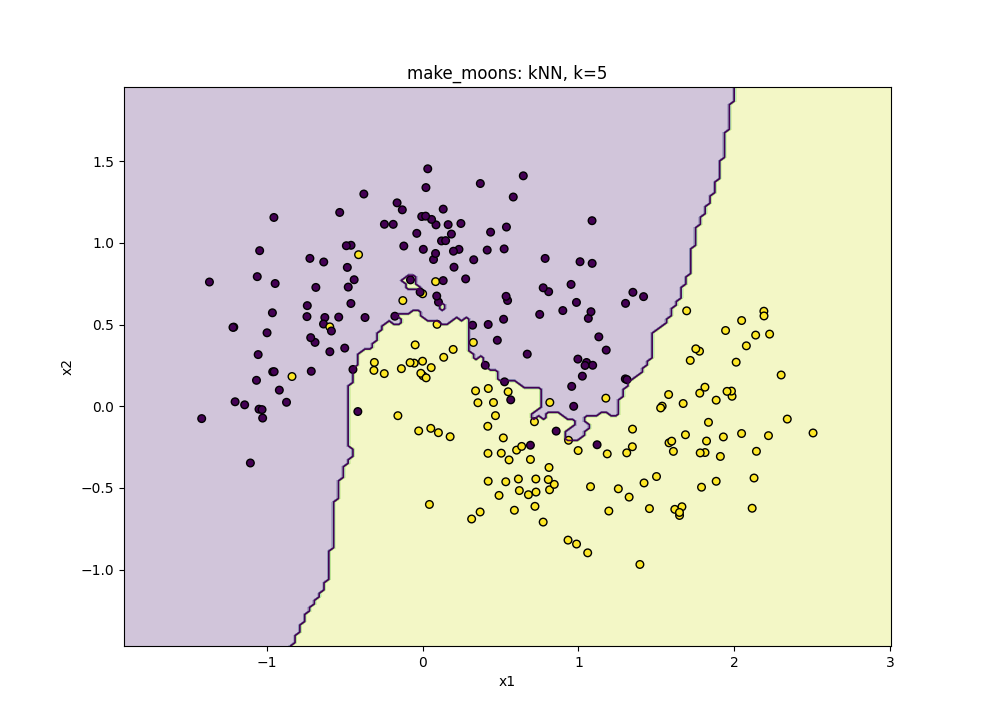

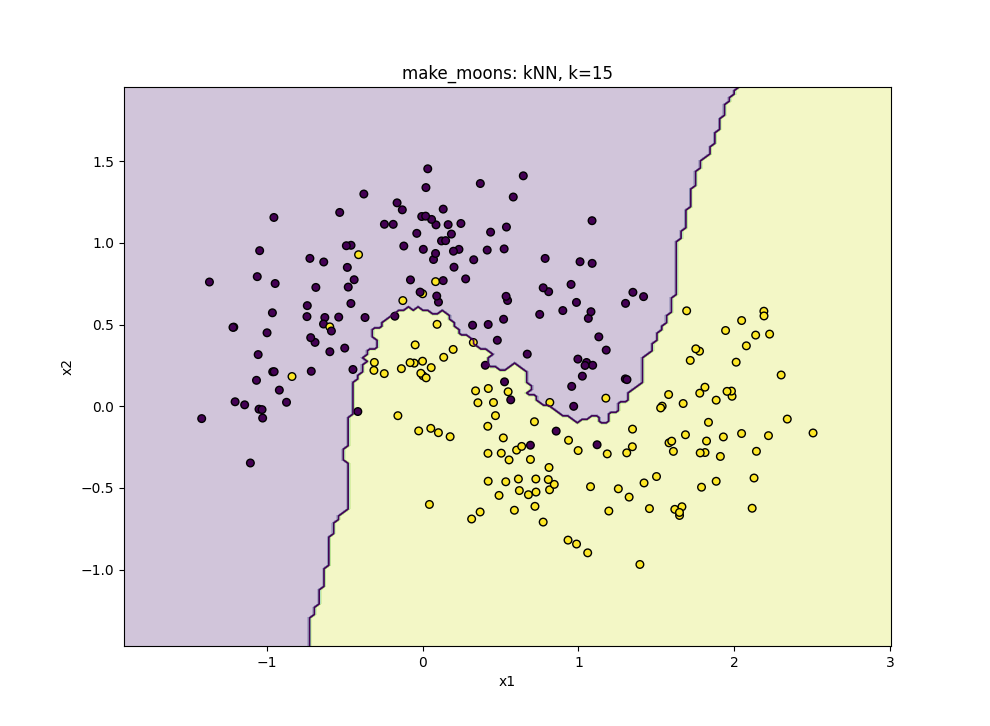

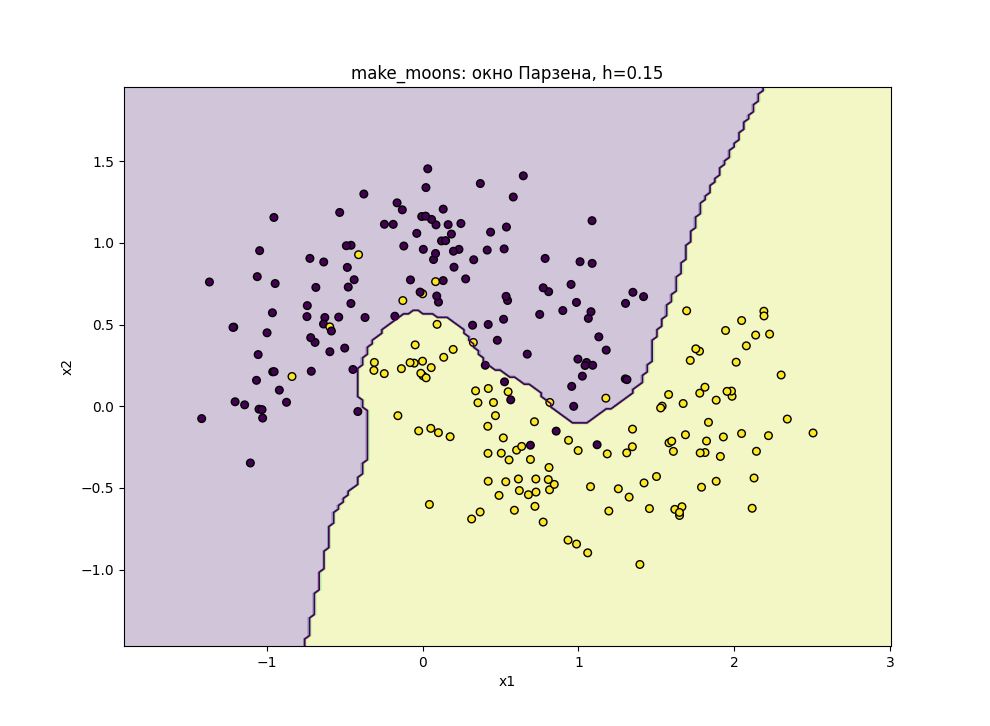

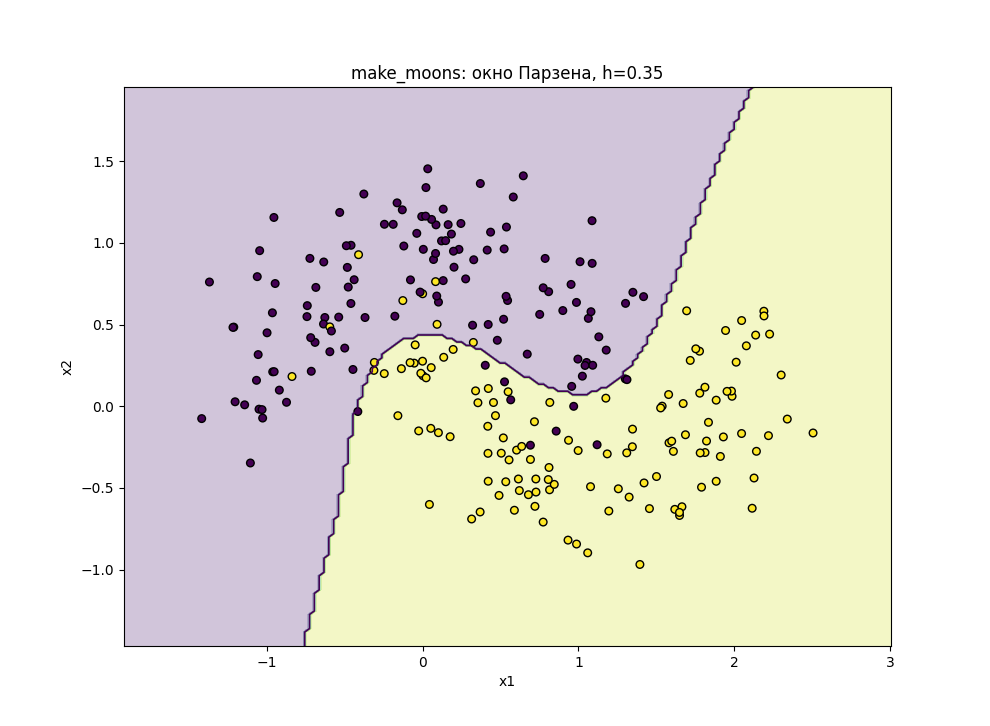

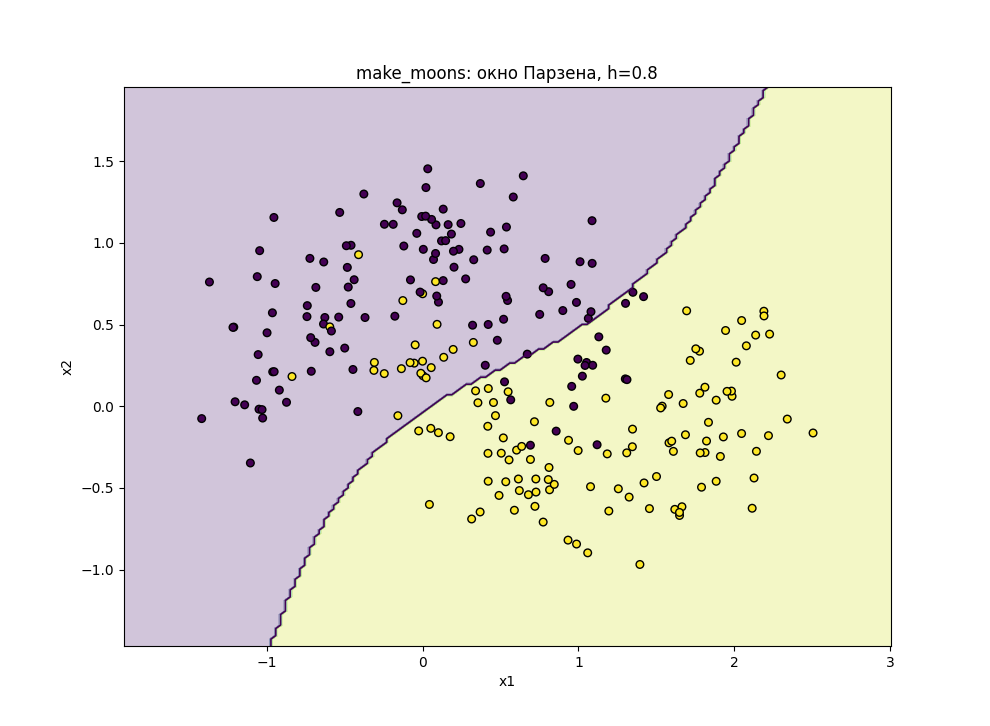

In [10]:

X_moons, y_moons = make_moons(n_samples=250, noise=0.25, random_state=42)


def plot_decision_map(X, y, method='knn', k=5, h=0.5, p=2, kernel='gaussian', title=''):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 160),
        np.linspace(y_min, y_max, 160)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    D = minkowski_distances(grid, X, p=p)
    pred = predict_from_distances(D, y, method=method, k=k, h=h, kernel=kernel)
    Z = pred.reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.25)
    # Явная граница решения между классами.
    plt.contour(xx, yy, Z, levels=[0.5], linewidths=1.2)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', s=30)
    plt.title(title)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.show()


for k in [1, 5, 15]:
    plot_decision_map(
        X_moons, y_moons,
        method='knn', k=k, p=2,
        title=f'make_moons: kNN, k={k}'
    )

for h in [0.15, 0.35, 0.8]:
    plot_decision_map(
        X_moons, y_moons,
        method='parzen_fixed', h=h, p=2, kernel='gaussian',
        title=f'make_moons: окно Парзена, h={h}'
    )


## Вывод по границам классификации
Малые значения k и h делают границу более чувствительной к отдельным точкам, а большие значения сглаживают решение. Параметры нужно выбирать так, чтобы модель не была слишком шумной, но сохраняла форму классов.


## Сравнение kNN и weighted-kNN


In [11]:

def compare_knn_weighted_on_noise(noise_values=(0.05, 0.15, 0.25, 0.35), repeats=20, k=15):
    rows = []

    for noise in noise_values:
        acc_knn_list = []
        acc_weighted_list = []

        for seed in range(repeats):
            X, y = make_moons(n_samples=400, noise=noise, random_state=seed)
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.3, random_state=seed, stratify=y
            )

            mean, std = standardize_fit(X_train)
            X_train = standardize_transform(X_train, mean, std)
            X_test = standardize_transform(X_test, mean, std)

            pred_knn = predict_metric_classifier(X_train, y_train, X_test, method='knn', k=k, p=2)
            pred_weighted = predict_metric_classifier(X_train, y_train, X_test, method='weighted_knn', k=k, p=2)

            acc_knn_list.append(accuracy(y_test, pred_knn))
            acc_weighted_list.append(accuracy(y_test, pred_weighted))

        knn_mean = np.mean(acc_knn_list)
        weighted_mean = np.mean(acc_weighted_list)
        diff = weighted_mean - knn_mean

        if diff > 0:
            comment = 'weighted-kNN лучше'
        elif diff < 0:
            comment = 'обычный kNN лучше'
        else:
            comment = 'одинаково'

        rows.append({
            'noise': noise,
            'k': k,
            'kNN_accuracy_mean': knn_mean,
            'kNN_accuracy_std': np.std(acc_knn_list),
            'weighted_kNN_accuracy_mean': weighted_mean,
            'weighted_kNN_accuracy_std': np.std(acc_weighted_list),
            'difference_weighted_minus_knn': diff,
            'comment': comment
        })

    return pd.DataFrame(rows)


weighted_comparison_table = compare_knn_weighted_on_noise(repeats=20, k=15)
weighted_comparison_table


,noise,k,kNN_accuracy_mean,kNN_accuracy_std,weighted_kNN_accuracy_mean,weighted_kNN_accuracy_std,difference_weighted_minus_knn,comment
0,0.05,15,1.000000,0.000000,1.000000,0.000000,0.000000,одинаково
1,0.15,15,0.986250,0.009601,0.987083,0.009673,0.000833,weighted-kNN лучше
2,0.25,15,0.936250,0.023463,0.932500,0.020052,-0.003750,обычный kNN лучше
3,0.35,15,0.881667,0.024238,0.872917,0.022496,-0.008750,обычный kNN лучше


## Вывод по weighted-kNN
weighted-kNN не является универсально лучшим методом. На make_moons разница с обычным kNN меняется при разных уровнях шума и обычно невелика по сравнению с разбросом между запусками. В этой задаче ранговое взвешивание немного помогло только при noise = 0.15, а при более сильном шуме обычный kNN оказался стабильнее. Поэтому преимущество weighted-kNN нужно проверять на конкретных данных, уровне шума и выбранном k.

## Профиль компактности


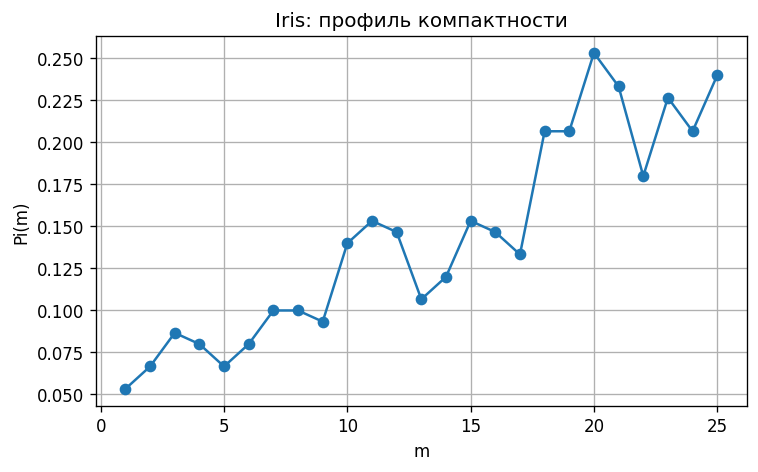

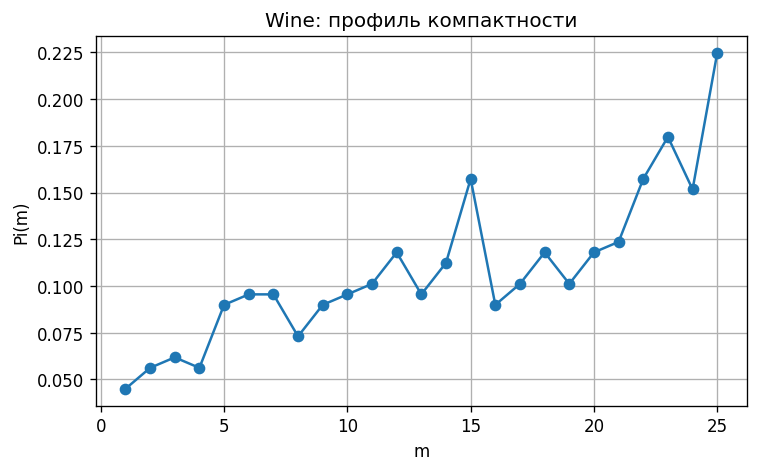

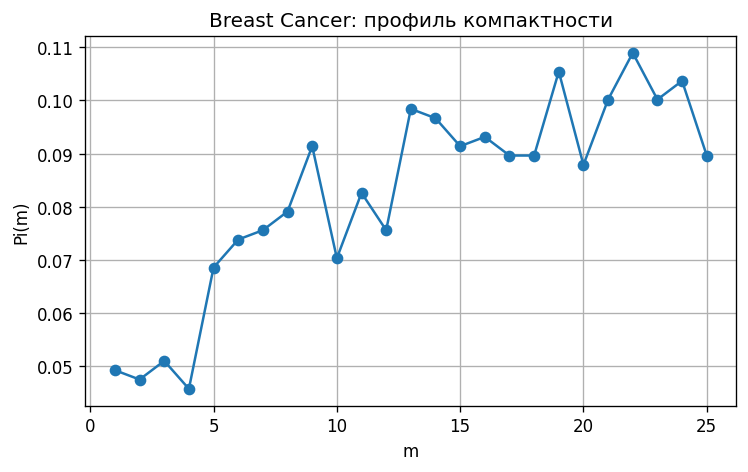

,dataset,Pi(1),1NN_LOO_error,comment
0,Iris,0.053333,0.053333,Pi(1) совпадает с LOO-ошибкой 1NN
1,Wine,0.044944,0.044944,Pi(1) совпадает с LOO-ошибкой 1NN
2,Breast Cancer,0.049209,0.049209,Pi(1) совпадает с LOO-ошибкой 1NN


In [12]:

def compactness_profile(X, y, p=2, max_m=30):
    D = minkowski_distances(X, X, p=p)
    np.fill_diagonal(D, np.inf)
    order = np.argsort(D, axis=1)

    max_m = min(max_m, X.shape[0] - 1)
    profile = []

    for m in range(1, max_m + 1):
        m_neighbor_idx = order[:, m - 1]
        errors = (y != y[m_neighbor_idx]).astype(float)
        profile.append(errors.mean())

    return np.arange(1, max_m + 1), np.asarray(profile)


profile_rows = []
for name, (X, y) in real_datasets.items():
    # Для профиля компактности используем одну и ту же стандартизированную матрицу признаков.
    X_scaled = standardize_all(X)
    m_values, profile = compactness_profile(X_scaled, y, p=2, max_m=25)
    one_nn_loo = loo_error(X_scaled, y, method='1nn', p=2, scale_inside=False)

    profile_rows.append({
        'dataset': name,
        'Pi(1)': profile[0],
        '1NN_LOO_error': one_nn_loo,
        'comment': 'Pi(1) совпадает с LOO-ошибкой 1NN'
    })

    plt.figure(figsize=(7, 4))
    plt.plot(m_values, profile, marker='o')
    plt.xlabel('m')
    plt.ylabel('Pi(m)')
    plt.title(f'{name}: профиль компактности')
    plt.grid(True)
    plt.show()

compactness_table = pd.DataFrame(profile_rows)
compactness_table


## Вывод по профилю компактности
Чем меньше значение Pi(1), тем чаще ближайший сосед имеет тот же класс и тем лучше работает 1NN. В экспериментах Pi(1) совпадает с LOO-ошибкой 1NN


## Жадный отбор эталонов


In [13]:

def one_nn_predict_with_prototypes(X_proto, y_proto, X_query, p=2):
    D = minkowski_distances(X_query, X_proto, p=p)
    nearest = np.argmin(D, axis=1)
    return y_proto[nearest]


def prototype_accuracy(X_train, y_train, X_val, y_val, selected_indices, p=2):
    selected_indices = np.asarray(selected_indices, dtype=int)
    pred = one_nn_predict_with_prototypes(X_train[selected_indices], y_train[selected_indices], X_val, p=p)
    return accuracy(y_val, pred)


def greedy_deletion_prototypes(X_train, y_train, X_val, y_val, p=2, tolerance=0.0, max_passes=2):
    selected = list(range(len(X_train)))
    current_acc = prototype_accuracy(X_train, y_train, X_val, y_val, selected, p=p)
    classes = set(np.unique(y_train))

    for _ in range(max_passes):
        changed = False
        for idx in selected.copy():
            trial = [j for j in selected if j != idx]
            if set(np.unique(y_train[trial])) != classes:
                continue

            trial_acc = prototype_accuracy(X_train, y_train, X_val, y_val, trial, p=p)
            if trial_acc >= current_acc - tolerance:
                selected = trial
                current_acc = trial_acc
                changed = True

        if not changed:
            break

    return np.asarray(selected), current_acc


def greedy_addition_prototypes(X_train, y_train, X_val, y_val, p=2, max_prototypes=30, min_improvement=0.0):
    classes = np.unique(y_train)
    selected = []

    # начинаю с 1 типичного объекта каждого класса,ближайшего к центру класса
    for cls in classes:
        cls_indices = np.where(y_train == cls)[0]
        center = X_train[cls_indices].mean(axis=0)
        distances_to_center = np.linalg.norm(X_train[cls_indices] - center, axis=1)
        selected.append(cls_indices[np.argmin(distances_to_center)])

    selected = list(dict.fromkeys(selected))
    current_acc = prototype_accuracy(X_train, y_train, X_val, y_val, selected, p=p)

    while len(selected) < min(max_prototypes, len(X_train)):
        best_idx = None
        best_acc = current_acc

        for candidate in range(len(X_train)):
            if candidate in selected:
                continue
            trial = selected + [candidate]
            trial_acc = prototype_accuracy(X_train, y_train, X_val, y_val, trial, p=p)
            if trial_acc > best_acc + min_improvement:
                best_acc = trial_acc
                best_idx = candidate

        if best_idx is None:
            break

        selected.append(best_idx)
        current_acc = best_acc

    return np.asarray(selected), current_acc


def measure_prediction_time_ms(X_proto, y_proto, X_query, repeats=200, p=2):
    start = time.perf_counter()
    for _ in range(repeats):
        _ = one_nn_predict_with_prototypes(X_proto, y_proto, X_query, p=p)
    end = time.perf_counter()
    return (end - start) * 1000 / repeats


In [14]:

prototype_rows = []

for name in ['Iris', 'Wine']:
    X, y = real_datasets[name]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    mean, std = standardize_fit(X_train)
    X_train = standardize_transform(X_train, mean, std)
    X_test = standardize_transform(X_test, mean, std)

    # Часть train используем как validation для выбора эталонов.
    X_base, X_val, y_base, y_val = train_test_split(
        X_train, y_train, test_size=0.25, random_state=42, stratify=y_train
    )

    # Настоящий baseline: 1NN по всей обучающей части после train/test-разделения.
    full_pred = one_nn_predict_with_prototypes(X_train, y_train, X_test, p=2)
    full_acc = accuracy(y_test, full_pred)
    full_time = measure_prediction_time_ms(X_train, y_train, X_test, repeats=300, p=2)

    del_indices, del_val_acc = greedy_deletion_prototypes(
        X_base, y_base, X_val, y_val, p=2, tolerance=0.0, max_passes=2
    )
    del_pred = one_nn_predict_with_prototypes(X_base[del_indices], y_base[del_indices], X_test, p=2)
    del_acc = accuracy(y_test, del_pred)
    del_time = measure_prediction_time_ms(X_base[del_indices], y_base[del_indices], X_test, repeats=300, p=2)

    add_indices, add_val_acc = greedy_addition_prototypes(
        X_base, y_base, X_val, y_val, p=2, max_prototypes=30
    )
    add_pred = one_nn_predict_with_prototypes(X_base[add_indices], y_base[add_indices], X_test, p=2)
    add_acc = accuracy(y_test, add_pred)
    add_time = measure_prediction_time_ms(X_base[add_indices], y_base[add_indices], X_test, repeats=300, p=2)

    prototype_rows.extend([
        {
            'dataset': name,
            'method': 'full train 1NN',
            'num_prototypes': len(X_train),
            'validation_accuracy': None,
            'test_accuracy': full_acc,
            'prediction_time_ms': full_time,
            'speedup_vs_full': 1.0
        },
        {
            'dataset': name,
            'method': 'greedy deletion',
            'num_prototypes': len(del_indices),
            'validation_accuracy': del_val_acc,
            'test_accuracy': del_acc,
            'prediction_time_ms': del_time,
            'speedup_vs_full': full_time / del_time
        },
        {
            'dataset': name,
            'method': 'greedy addition',
            'num_prototypes': len(add_indices),
            'validation_accuracy': add_val_acc,
            'test_accuracy': add_acc,
            'prediction_time_ms': add_time,
            'speedup_vs_full': full_time / add_time
        }
    ])

prototype_table = pd.DataFrame(prototype_rows)
prototype_table


,dataset,method,num_prototypes,validation_accuracy,test_accuracy,prediction_time_ms,speedup_vs_full
0,Iris,full train 1NN,105,NaN,0.933333,0.271726,1.000000
1,Iris,greedy deletion,5,1.000000,0.911111,0.029945,9.074306
2,Iris,greedy addition,4,1.000000,0.888889,0.026695,10.179072
3,Wine,full train 1NN,124,NaN,0.962963,0.777146,1.000000
4,Wine,greedy deletion,5,0.967742,0.907407,0.042054,18.479917
5,Wine,greedy addition,3,0.967742,0.907407,0.033868,22.946317


## Вывод по отбору эталонов
Жадный отбор эталонов позволяет сократить количество объектов, используемых в 1NN, и ускорить предсказание. При этом качество может немного снизиться, поэтому выбранные эталоны нужно проверять на независимой тестовой выборке.

## Итоговые выводы

1. Качество метрических методов зависит от выбора параметров: k, p, h, типа ядра и масштабирования.
2. Масштабирование особенно важно для датасетов, где признаки имеют разные диапазоны значений.
3. Профиль компактности подтвердил связь между локальным расположением объектов и качеством 1NN.
4. weighted-kNN может быть устойчивее обычного kNN в отдельных условиях, но не является универсально лучшим методом.
5. Жадный отбор эталонов ускоряет 1NN и уменьшает число объектов, используемых при предсказании, но итоговое качество нужно проверять на тестовой выборке.
